In [ ]:
from typing import Annotated, TypedDict

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


In [24]:
llm = ChatOllama(
    model="huihui_ai/qwen3.5-abliterated:0.8b",
    temperature=0.7,
    reasoning=False,
)


@tool
def add(num1: int, num2: int):
    """adds two numbers"""
    return num1 + num2


@tool
def subtract(num1: int, num2: int):
    """subtracts two numbers [num1 - num2]"""
    return num1 - num2


@tool
def multiply(num1: int, num2: int):
    """multiplies two numbers"""
    return num1 * num2


@tool
def divide(num1: int, num2: int):
    """divides two numbers"""
    return num1 / num2


tools = [add, subtract, multiply, divide]
llm.bind_tools(tools)

_ChatModelBinding(bound=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, model='huihui_ai/qwen3.5-abliterated:0.8b', reasoning=False, temperature=0.7), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'adds two numbers', 'parameters': {'properties': {'num1': {'type': 'integer'}, 'num2': {'type': 'integer'}}, 'required': ['num1', 'num2'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'subtract', 'description': 'subtracts two numbers [num1 - num2]', 'parameters': {'properties': {'num1': {'type': 'integer'}, 'num2': {'type': 'integer'}}, 'required': ['num1', 'num2'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'multiplies two numbers', 'parameters': {'properties': {'num1': {'type': 'integer'}, 'num2': {'type': 'integer'}}, 'required': ['num1', 'num2'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'divide', 'description': 'divides two num

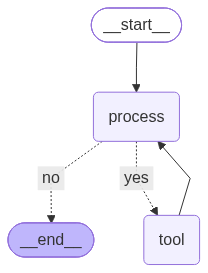

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


async def process_node(state: AgentState) -> AgentState:
    system_prompt = SystemMessage("You are a helpful assistant")
    response = await llm.ainvoke([system_prompt, *state["messages"]])
    return AgentState(messages=[response])


def should_call_tools(state: AgentState) -> str:
    last_msg = state["messages"][-1]
    if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
        return "yes"
    else:
        return "no"


graph = StateGraph(AgentState)
graph.add_node("process", process_node)

tool_node = ToolNode(tools)
graph.add_node("tool", tool_node)

graph.add_edge(START, "process")
graph.add_conditional_edges(
    "process",
    should_call_tools,
    {
        "yes": "tool",
        "no": END,
    },
)
graph.add_edge("tool", "process")

app = graph.compile()
app

In [32]:

agent_state = AgentState(messages=[HumanMessage("Hey what is 34 + 53, taking the result dividing it by 7 then multiplying result by 20, and after that tell me a nice joke")])
response = await app.ainvoke(agent_state)
print(response['messages'][-1].content)

for msg in response['messages']:
    print(msg)

First, let's tackle the math puzzle!

**Step 1: Calculate the sum**
34 + 53 = **87**

**Step 2: Divide by 7**
87 ÷ 7 ≈ **12.42857**

**Step 3: Multiply by 20**
12.42857 × 20 ≈ **248.57**

So, your result is roughly **248.57**. Now, let's tell you a nice joke!

**The "Lazy Tuesday" Joke**

Why did the accountant complain about his weekly report?
Because he was told to spend 20% of his salary on the weekend, but he didn't want to spend anything!

The accountant: "I'm saving you the money!"

The accountant: "I'm going to give you a 50% discount instead!"

The accountant: "Why not? You're saving me the time!"

**Final Result:**
After all the math, here is your **248.57**!

Now, who is the "Lazy Tuesday" accountant?
content='Hey what is 34 + 53, taking the result dividing it by 7 then multiplying result by 20, and after that tell me a nice joke' additional_kwargs={} response_metadata={} id='3a0e7187-7c6a-4972-b1c0-d6df157aaf04'
content='First, let\'s tackle the math puzzle!\n\n**Step 1: Cal